In [4]:
print("Read and draw dead areas in the detector")

Read and draw dead areas in the detector


Input directory:  /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out/24308437_0/v10_06_00/nu_spill/data/1
Dead areas:
[[9.52643, 4.2], [9.87284, 4.2], [199.965, 333.45], [199.965, 334.05]]
[[-11.6046, 4.2], [-11.2582, 4.2], [199.965, 370.05], [199.965, 370.65]]
[[77.0761, 4.2], [77.4225, 4.2], [-199.965, 484.65], [-199.965, 484.05]]
[[199.965, 61.9495], [199.965, 81.1495], [-44.8604, 505.2], [-55.9455, 505.2]]
[[199.965, 283.949], [199.965, 284.549], [72.5727, 505.2], [72.2263, 505.2]]
[[-199.965, 61.8], [199.965, 61.8], [199.965, 71.4], [-199.965, 71.4]]
[[-199.965, 126.0], [199.965, 126.0], [199.965, 126.3], [-199.965, 126.3]]
[[-199.965, 253.8], [199.965, 253.8], [199.965, 255.6], [-199.965, 255.6]]
[[-199.965, 331.8], [199.965, 331.8], [199.965, 332.1], [-199.965, 332.1]]
[[-199.965, 383.1], [199.965, 383.1], [199.965, 383.4], [-199.965, 383.4]]
[[-199.359, 504.6], [199.359, 504.6], [199.012, 505.2], [-199.012, 505.2]]


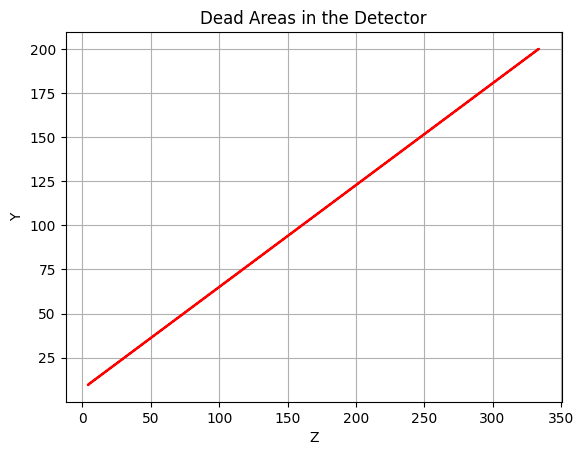

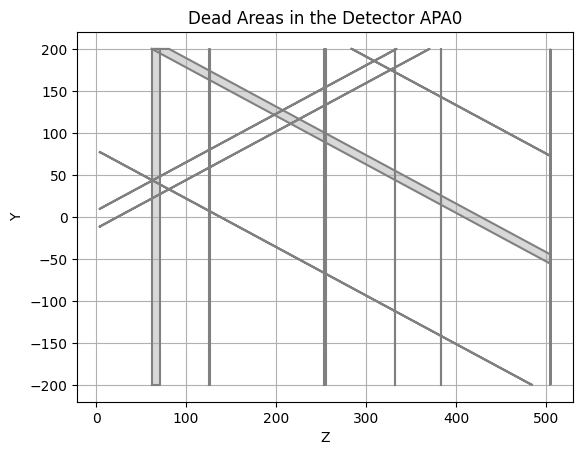

Y min:  -199.965
Y max:  199.965
Z min:  4.2
Z max:  504.6


In [5]:
# Read dead area from a json file
import json
from pathlib import Path
import matplotlib.pyplot as plt


event=1
SUBDIR="24308437_0"
SBNDCODE_VERSION    = "v10_06_00"   # Use the latest version available
PROCESS             = "nu_spill"    # options: "nu_spill", "cosmic_spill"
apa                 = "APA0"

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out/")
OUTDIR=OUTDIR/SUBDIR/SBNDCODE_VERSION/PROCESS
NEWOUTDIR= OUTDIR/"data"/str(event)
print("Input directory: ", NEWOUTDIR)

dead_area_file = NEWOUTDIR/(str(event) + "-channel-deadarea.json")

with open(dead_area_file, "r") as f:
    dead_areas = json.load(f)

# Print the dead areas
print("Dead areas:")
for area in dead_areas:
    print(area)

# read each row as x,y coordinates of one dead area and draw it on a plot only for the first 1 dead area
for area in dead_areas[:1]:
    point0 = area[0]
    point1 = area[1]
    point2 = area[2]
    point3 = area[3]
    y = [point0[0], point1[0], point2[0], point3[0], point0[0]]
    z = [point0[1], point1[1], point2[1], point3[1], point0[1]]
    plt.plot(z, y, 'r-')
plt.xlabel('Z')
plt.ylabel('Y')
plt.title('Dead Areas in the Detector')
plt.grid()
plt.show()

# read each row as x,y coordinates of one dead area and draw it on a plot only for the all dead areas
for area in dead_areas:
    point0 = area[0]
    point1 = area[1]
    point2 = area[2]
    point3 = area[3]
    y = [point0[0], point1[0], point2[0], point3[0], point0[0]]
    z = [point0[1], point1[1], point2[1], point3[1], point0[1]]
    plt.plot(z, y, 'grey')
    plt.fill(z, y, 'grey', alpha=0.3, linewidth=0.0, edgecolor='grey')
             
plt.xlabel('Z')
plt.ylabel('Y')
plt.title(f'Dead Areas in the Detector {apa}')
plt.grid()
#plt.show()

# save this plot as a png file
plt.savefig("dead-areas_{}.png".format(apa))
plt.show(block=False)

#print min and max of y and z coordinates of the dead areas
y_min = min([area[0][0] for area in dead_areas])
y_max = max([area[0][0] for area in dead_areas])
z_min = min([area[0][1] for area in dead_areas])
z_max = max([area[0][1] for area in dead_areas])
print("Y min: ", y_min)
print("Y max: ", y_max)
print("Z min: ", z_min)
print("Z max: ", z_max)


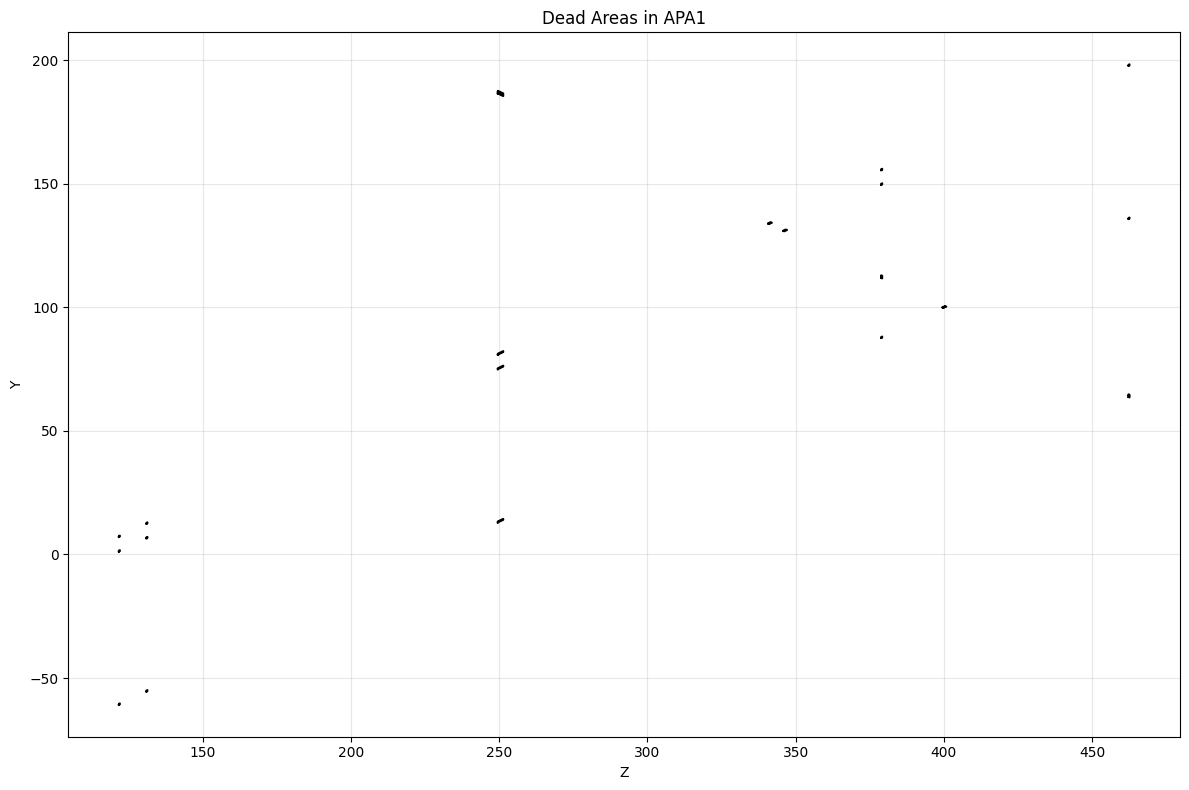

Number of dead areas in APA1: 26
Y range: [-60.79, 198.32]
Z range: [121.80, 462.60]


In [6]:
# Read APA1 dead areas and draw in black
import json
from pathlib import Path

# Load APA1 dead area data
apa1_file = Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/developcode/wcp-porting-validation/sbnd/data/0/0-channel-deadarea-apa1-face0.json")

with open(apa1_file, "r") as f:
    dead_areas_apa1 = json.load(f)

# Create a new figure for APA1
fig, ax = plt.subplots(figsize=(12, 8))

# Draw all APA1 dead areas in black
for area in dead_areas_apa1:
    point0 = area[0]
    point1 = area[1]
    point2 = area[2]
    point3 = area[3]
    y = [point0[0], point1[0], point2[0], point3[0], point0[0]]
    z = [point0[1], point1[1], point2[1], point3[1], point0[1]]
    ax.plot(z, y, 'k-', linewidth=1.5)
    ax.fill(z, y, 'black', alpha=0.3, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Z')
ax.set_ylabel('Y')
ax.set_title('Dead Areas in APA1')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dead-areas_APA1.png", dpi=150)
plt.show()

# Print statistics
y_coords = [coord[0] for area in dead_areas_apa1 for coord in area]
z_coords = [coord[1] for area in dead_areas_apa1 for coord in area]
print(f"Number of dead areas in APA1: {len(dead_areas_apa1)}")
print(f"Y range: [{min(y_coords):.2f}, {max(y_coords):.2f}]")
print(f"Z range: [{min(z_coords):.2f}, {max(z_coords):.2f}]")